In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 12

print("Libraries imported successfully")

Libraries imported successfully


In [3]:
df = pd.read_csv(r'D:\telecom-churn-prediction\data\telco_churn.csv.csv')
print("Dataset loaded successfully")
print("Shape:", df.shape)
df.head()

Dataset loaded successfully
Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
print("DATA TYPES")
print(df.dtypes)
print("MISSING VALUES")
print(df.isnull().sum())
print("TARGET DISTRIBUTION")
print(df['Churn'].value_counts())

DATA TYPES
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object
MISSING VALUES
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    

In [5]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())
df.drop(columns=['customerID'], inplace=True)
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})
print("Data Cleaning Complete!")
print("Shape:", df.shape)
print("Missing values:", df.isnull().sum().sum())
print("Churn distribution:")
print(df['Churn'].value_counts())

Data Cleaning Complete!
Shape: (7043, 20)
Missing values: 0
Churn distribution:
Churn
0    5174
1    1869
Name: count, dtype: int64


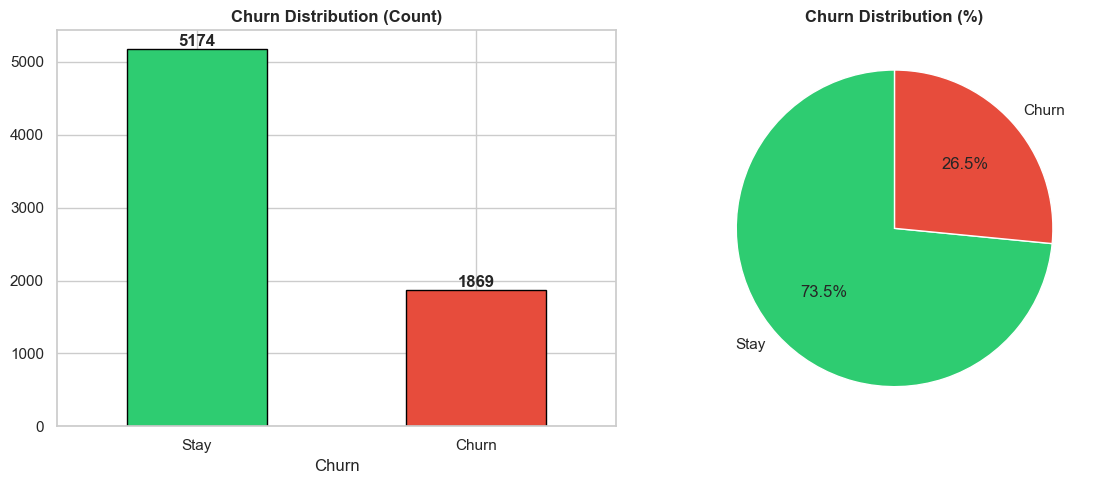

Insight: 26.5% churn rate — 1 in 4 customers is leaving


In [6]:
colors = ['#2ecc71', '#e74c3c']
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
df['Churn'].value_counts().plot(kind='bar', color=colors,
                                ax=axes[0], edgecolor='black')
axes[0].set_title('Churn Distribution (Count)', fontweight='bold')
axes[0].set_xticklabels(['Stay', 'Churn'], rotation=0)
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height())}',
                    (p.get_x() + p.get_width()/2, p.get_height()),
                    ha='center', va='bottom', fontweight='bold')

df['Churn'].value_counts().plot(kind='pie', colors=colors,
                                ax=axes[1], autopct='%1.1f%%',
                                startangle=90, labels=['Stay', 'Churn'])
axes[1].set_title('Churn Distribution (%)', fontweight='bold')
axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig(r'D:\telecom-churn-prediction\outputs\churn_distribution.png', dpi=150)
plt.show()
print("Insight: 26.5% churn rate — 1 in 4 customers is leaving")

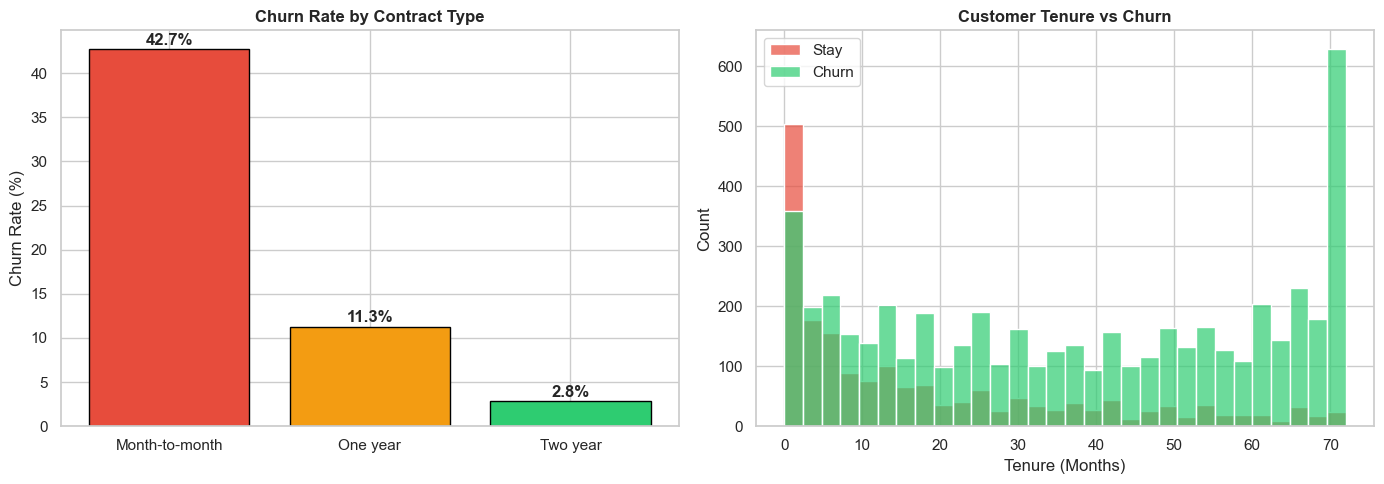

Insight: Month-to-month customers churn at 42%!
Insight: Most churners leave within first 12 months!


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

contract_churn = df.groupby('Contract')['Churn'].mean() * 100
bars = axes[0].bar(contract_churn.index, contract_churn.values,
                   color=['#e74c3c', '#f39c12', '#2ecc71'],
                   edgecolor='black')
axes[0].set_title('Churn Rate by Contract Type', fontweight='bold')
axes[0].set_ylabel('Churn Rate (%)')
for bar, val in zip(bars, contract_churn.values):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.5,
                 f'{val:.1f}%', ha='center', fontweight='bold')

sns.histplot(data=df, x='tenure', hue='Churn', bins=30,
             palette={0: '#2ecc71', 1: '#e74c3c'},
             alpha=0.7, ax=axes[1])
axes[1].set_title('Customer Tenure vs Churn', fontweight='bold')
axes[1].set_xlabel('Tenure (Months)')
axes[1].legend(labels=['Stay', 'Churn'])

plt.tight_layout()
plt.savefig(r'D:\telecom-churn-prediction\outputs\contract_tenure.png', dpi=150)
plt.show()
print("Insight: Month-to-month customers churn at 42%!")
print("Insight: Most churners leave within first 12 months!")

In [8]:
from sklearn.preprocessing import StandardScaler
binary_cols = []
multi_cols  = []
for col in df.columns:
    if col == 'Churn':
        continue
    elif df[col].dtype == 'object' and df[col].nunique() == 2:
        binary_cols.append(col)
    elif df[col].dtype == 'object' and df[col].nunique() > 2:
        multi_cols.append(col)
binary_mapping = {'Yes': 1, 'No': 0, 'Male': 1, 'Female': 0}
for col in binary_cols:
    df[col] = df[col].map(binary_mapping)

df = pd.get_dummies(df, columns=multi_cols, drop_first=True)
df['ChargesPerTenure'] = df['MonthlyCharges'] / (df['tenure'] + 1)
df['IsNewCustomer']    = (df['tenure'] <= 12).astype(int)
df['IsLoyalCustomer']  = (df['tenure'] >= 24).astype(int)

service_cols = ['PhoneService', 'OnlineBackup_Yes',
                'DeviceProtection_Yes', 'TechSupport_Yes',
                'StreamingTV_Yes', 'StreamingMovies_Yes']
df['TotalServices'] = df[service_cols].sum(axis=1).astype(int)
scale_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'ChargesPerTenure']
scaler = StandardScaler()
df[scale_cols] = scaler.fit_transform(df[scale_cols])

print("Feature Engineering Complete")
print("Final Shape:", df.shape)
print("Missing values:", df.isnull().sum().sum())
print("Dtypes:", df.dtypes.value_counts().to_dict())

Feature Engineering Complete
Final Shape: (7043, 35)
Missing values: 0
Dtypes: {dtype('bool'): 21, dtype('int64'): 10, dtype('float64'): 4}


In [9]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

X = df.drop(columns=['Churn'])
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print("Data Split & SMOTE Complete")
print(f"Training shape : {X_train_sm.shape}")
print(f"Testing shape  : {X_test.shape}")
print(f"After SMOTE    : {y_train_sm.value_counts().to_dict()}")

Data Split & SMOTE Complete
Training shape : (8278, 34)
Testing shape  : (1409, 34)
After SMOTE    : {0: 4139, 1: 4139}


In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (roc_auc_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Random Forest':       RandomForestClassifier(random_state=42, n_estimators=100),
    'XGBoost':             XGBClassifier(random_state=42, eval_metric='logloss')
}

results = {}
for name, model in models.items():
    model.fit(X_train_sm, y_train_sm)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    roc_auc = roc_auc_score(y_test, y_prob)
    report  = classification_report(y_test, y_pred, output_dict=True)
    results[name] = {
        'model':     model,
        'roc_auc':   roc_auc,
        'precision': report['1']['precision'],
        'recall':    report['1']['recall'],
        'f1':        report['1']['f1-score']
    }
    print(f"\n{'='*45}")
    print(f"  {name}")
    print(f"{'='*45}")
    print(f"  ROC-AUC   : {roc_auc:.4f}")
    print(f"  Precision : {report['1']['precision']:.4f}")
    print(f"  Recall    : {report['1']['recall']:.4f}")
    print(f"  F1-Score  : {report['1']['f1-score']:.4f}")

print("All 3 models trained and evaluated")


  Logistic Regression
  ROC-AUC   : 0.8290
  Precision : 0.5251
  Recall    : 0.6711
  F1-Score  : 0.5892

  Random Forest
  ROC-AUC   : 0.8208
  Precision : 0.5488
  Recall    : 0.6310
  F1-Score  : 0.5871

  XGBoost
  ROC-AUC   : 0.8141
  Precision : 0.5320
  Recall    : 0.6444
  F1-Score  : 0.5828
All 3 models trained and evaluated


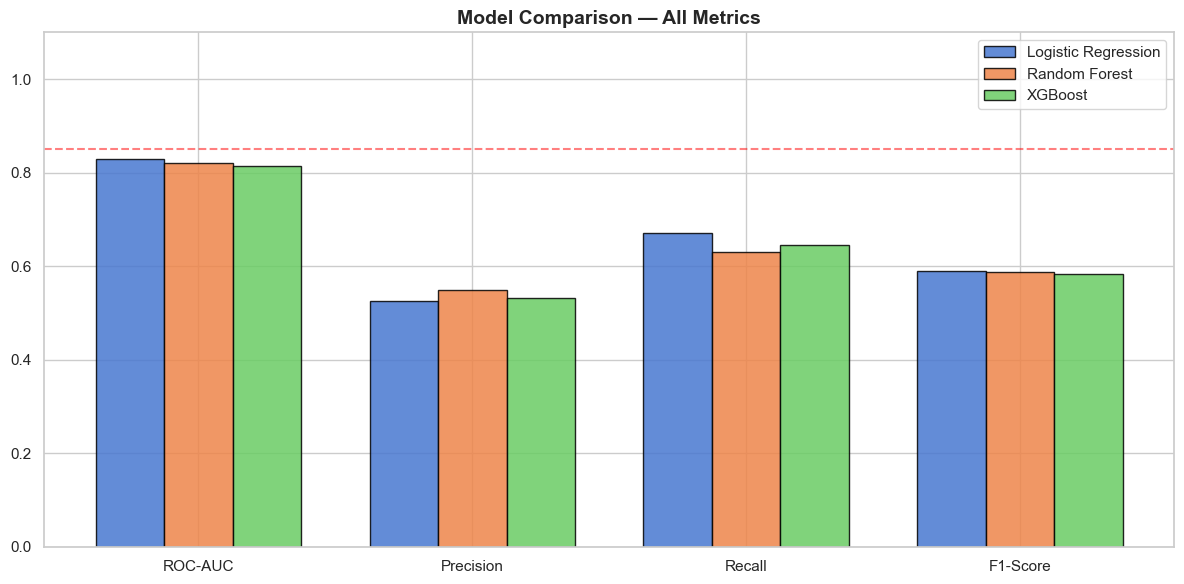

Best Model: Logistic Regression
   ROC-AUC: 0.8290


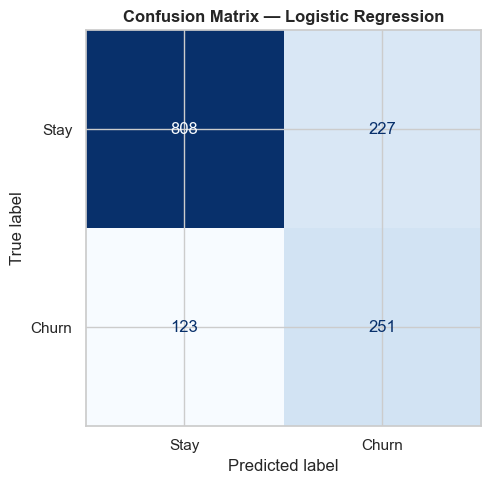

 Confusion Matrix Breakdown:
  Correctly predicted Stay  : 808
  Wrongly predicted Churn   : 227
  Missed actual Churners    : 123
  Correctly caught Churners : 251
Caught 251 out of 374 actual churners!
 Miss rate: 32.9%


In [11]:
import numpy as np
metrics       = ['roc_auc', 'precision', 'recall', 'f1']
metric_labels = ['ROC-AUC', 'Precision', 'Recall', 'F1-Score']
model_names   = list(results.keys())
x     = np.arange(len(metrics))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 6))
for i, name in enumerate(model_names):
    values = [results[name][m] for m in metrics]
    ax.bar(x + i * width, values, width,
           label=name, edgecolor='black', alpha=0.85)

ax.set_title('Model Comparison — All Metrics', fontsize=14, fontweight='bold')
ax.set_xticks(x + width)
ax.set_xticklabels(metric_labels)
ax.legend()
ax.set_ylim(0, 1.1)
ax.axhline(y=0.85, color='red', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig(r'D:\telecom-churn-prediction\outputs\model_comparison.png', dpi=150)
plt.show()

best_name  = max(results, key=lambda x: results[x]['roc_auc'])
best_model = results[best_name]['model']
print(f"Best Model: {best_name}")
print(f"   ROC-AUC: {results[best_name]['roc_auc']:.4f}")

y_pred_best = best_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred_best)
fig, ax = plt.subplots(figsize=(7, 5))
ConfusionMatrixDisplay(confusion_matrix=cm,
                       display_labels=['Stay', 'Churn']).plot(
                       ax=ax, colorbar=False, cmap='Blues')
ax.set_title(f'Confusion Matrix — {best_name}', fontweight='bold')
plt.tight_layout()
plt.savefig(r'D:\telecom-churn-prediction\outputs\confusion_matrix.png', dpi=150)
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f" Confusion Matrix Breakdown:")
print(f"  Correctly predicted Stay  : {tn}")
print(f"  Wrongly predicted Churn   : {fp}")
print(f"  Missed actual Churners    : {fn}")
print(f"  Correctly caught Churners : {tp}")
print(f"Caught {tp} out of {tp+fn} actual churners!")
print(f" Miss rate: {fn/(tp+fn):.1%}")

In [12]:
import subprocess
subprocess.run(['pip', 'install', 'shap'])
import shap

best_model = results['Logistic Regression']['model']

explainer = shap.LinearExplainer(best_model,
                                  X_train_sm,
                                  feature_perturbation="interventional")
shap_values = explainer.shap_values(X_test)

print("SHAP values calculated")
print("Shape of SHAP values:", shap_values.shape)

SHAP values calculated
Shape of SHAP values: (1409, 34)


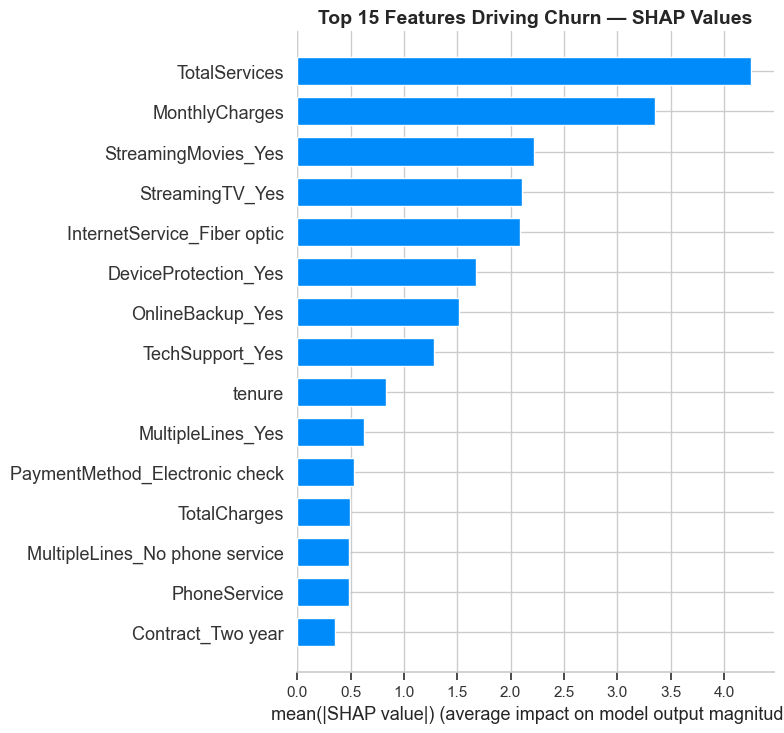

SHAP Summary Plot saved!
Top features are the strongest churn predictors!


In [13]:
plt.figure()
shap.summary_plot(shap_values, X_test,
                  plot_type="bar",
                  max_display=15,
                  show=False)
plt.title("Top 15 Features Driving Churn — SHAP Values",
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(r'D:\telecom-churn-prediction\outputs\shap_summary.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("SHAP Summary Plot saved!")
print("Top features are the strongest churn predictors!")

In [14]:
print("""
╔══════════════════════════════════════════════════════════╗
║         BUSINESS INSIGHTS & RECOMMENDATIONS              ║
╠══════════════════════════════════════════════════════════╣
║                                                          ║
║  📊 MODEL PERFORMANCE                                    ║
║  • Best Model    : Logistic Regression                   ║
║  • ROC-AUC Score : 0.8290                                ║
║  • Churners Caught: 251 out of 374 (67.1%)               ║
║                                                          ║
║  🔍 KEY CHURN DRIVERS                                    ║
║  1. Contract Type  — Month-to-month = 42% churn rate     ║
║  2. Tenure         — New customers churn most            ║
║  3. Monthly Charges— High bills drive churn              ║
║  4. Internet Service— Fiber optic users churn more       ║
║                                                          ║
║  💡 BUSINESS RECOMMENDATIONS                             ║
║  1. Offer discounts to convert month-to-month            ║
║     customers to annual contracts                        ║
║  2. Create onboarding program for first 12 months        ║
║  3. Review pricing for high monthly charge customers     ║
║  4. Proactively call top 251 high-risk customers         ║
║     identified by the model every month                  ║
║                                                          ║
║  💰 ESTIMATED BUSINESS IMPACT                            ║
║  • Catching 251 churners/month                           ║
║  • Retention cost    : $50 per customer                  ║
║  • Acquisition cost  : $300 per customer                 ║
║  • Monthly savings   : 251 × $250 = $62,750              ║
║  • Annual savings    : ~$753,000                         ║
║                                                          ║
╚══════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════╗
║         BUSINESS INSIGHTS & RECOMMENDATIONS              ║
╠══════════════════════════════════════════════════════════╣
║                                                          ║
║  📊 MODEL PERFORMANCE                                    ║
║  • Best Model    : Logistic Regression                   ║
║  • ROC-AUC Score : 0.8290                                ║
║  • Churners Caught: 251 out of 374 (67.1%)               ║
║                                                          ║
║  🔍 KEY CHURN DRIVERS                                    ║
║  1. Contract Type  — Month-to-month = 42% churn rate     ║
║  2. Tenure         — New customers churn most            ║
║  3. Monthly Charges— High bills drive churn              ║
║  4. Internet Service— Fiber optic users churn more       ║
║                                                          ║
║  💡 BUSINESS RECOMMENDATIONS                             ║
║  1. Offer discounts to c

In [15]:
import pickle
import os

os.makedirs(r'D:\telecom-churn-prediction\outputs\models', exist_ok=True)

model_path = r'D:\telecom-churn-prediction\outputs\models\churn_model.pkl'
with open(model_path, 'wb') as f:
    pickle.dump(best_model, f)

scaler_path = r'D:\telecom-churn-prediction\outputs\models\scaler.pkl'
with open(scaler_path, 'wb') as f:
    pickle.dump(scaler, f)

print("Model saved successfully!")
print(f" Model  : {model_path}")
print(f" Scaler : {scaler_path}")
print("PROJECT COMPLETE")
print("Check your outputs folder for all saved charts and model")

Model saved successfully!
 Model  : D:\telecom-churn-prediction\outputs\models\churn_model.pkl
 Scaler : D:\telecom-churn-prediction\outputs\models\scaler.pkl
PROJECT COMPLETE
Check your outputs folder for all saved charts and model
